<a href="https://colab.research.google.com/github/abinaya-345/AI-ML-Internship-Projects/blob/main/Iris_Flower_Clustering_Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, adjusted_rand_score

In [2]:
#Load Iris dataset directly
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["True_Label"] = y

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True_Label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
#Explore the dataset
print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   True_Label         150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True_Label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
#Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
True_Label           0
dtype: int64


In [5]:
#Standardize the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data scaling completed!")

Data scaling completed!


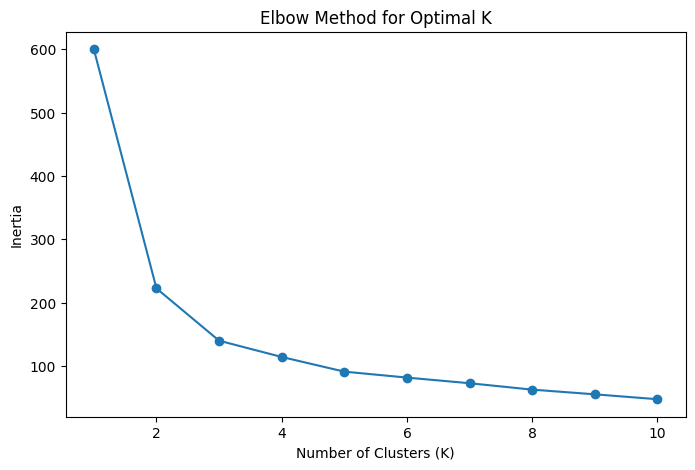

In [7]:
#Find the best K using Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [8]:
#Apply K-Means with k=3
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

predicted_clusters = kmeans.fit_predict(X_scaled)

df["Predicted_Cluster"] = predicted_clusters

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True_Label,Predicted_Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


In [9]:
#PCA dimensionality reduction
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape)
print("Reduced dimensions:", X_pca.shape)

Original dimensions: (150, 4)
Reduced dimensions: (150, 2)


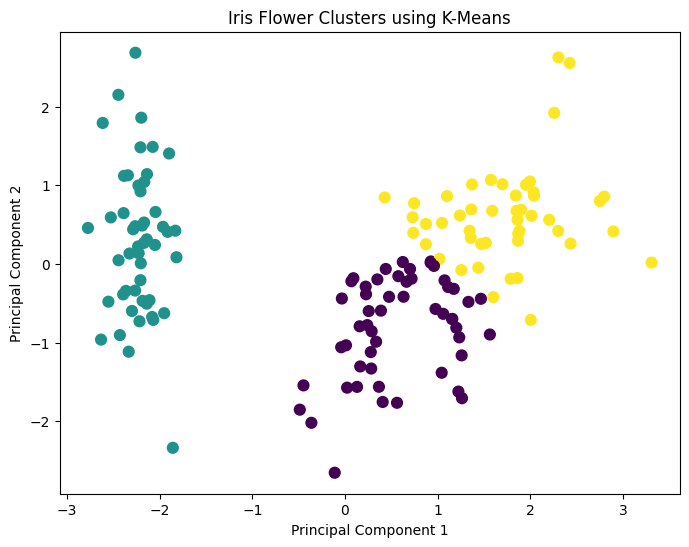

In [10]:
#Visualize K-Means clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=predicted_clusters,
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Flower Clusters using K-Means")

plt.show()

In [11]:
#Compare predicted clusters with true labels
comparison = pd.DataFrame({
    "True_Label": y,
    "Predicted_Cluster": predicted_clusters
})

comparison.head(20)

,True_Label,Predicted_Cluster
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,0,1
8,0,1
9,0,1


In [12]:
#Compare using Adjusted Rand Index
ari_score = adjusted_rand_score(
    y,
    predicted_clusters
)

print("Adjusted Rand Index:", ari_score)

Adjusted Rand Index: 0.6201351808870379


In [13]:
#Confusion matrix
cm = confusion_matrix(y, predicted_clusters)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 0 50  0]
 [39  0 11]
 [14  0 36]]


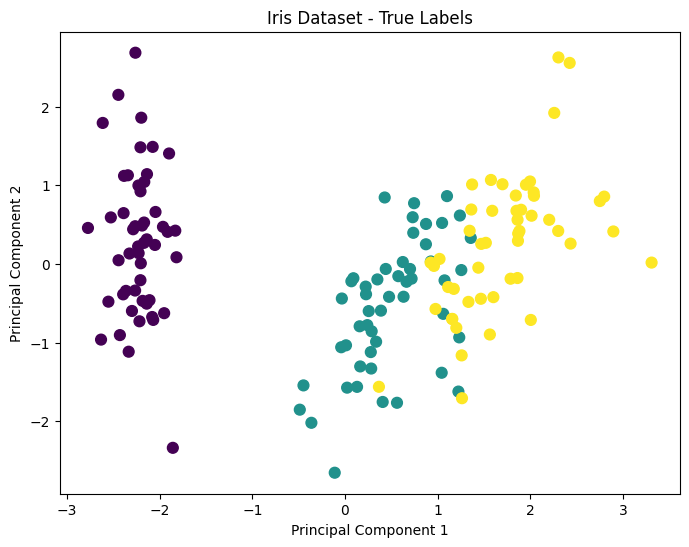

In [14]:
#Final visualization: True labels
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset - True Labels")

plt.show()

In [15]:
#Save your clustering results
df.to_csv("iris_clustering_results.csv", index=False)

print("Clustering results saved successfully!")

Clustering results saved successfully!
